<a href="https://colab.research.google.com/github/diomani-ouattara/Portfolio-Data-scientist/blob/main/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Term Deposit Marketing:** Predict if the customer will subscribe (yes/no) to a term deposit (variable y)

In [3]:

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from google.colab import files
import shap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

**Loading the Dataset**

In [4]:
print("Please upload your Term deposit file:")
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

Please upload your Term deposit file:


Saving term-deposit-marketing-2020.csv to term-deposit-marketing-2020.csv


Checking the 5 first lines of the dataset

In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In Education we don't know for everyone which kind of education they have, Not everyone has his contact in the dataset as well





Checking the 5 last lines of the dataset

In [6]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no
39999,38,technician,married,secondary,no,1442,yes,no,cellular,3,jun,113,1,no


In [7]:
# Let us see the info of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


There are 40000 observations and 13 columns in the dataset. All the columns have 40000 non-null values, i.e., there are no missing values in the data.  Some are  numericals  and Some are categoricals

In [8]:
# Checking unique values in each column
df.nunique()

,0
age,70
job,12
marital,3
education,4
default,2
balance,6849
housing,2
loan,2
contact,3
day,31


In [9]:
# Checking for any missing values just in case
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


It is hence confirmed that there are **no missing values** in this dataset

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,40000.0,40.544600,9.641776,19.0,33.0,39.0,48.0,95.0
balance,40000.0,1274.277550,2903.769716,-8019.0,54.0,407.0,1319.0,102127.0
day,40000.0,16.017225,8.278127,1.0,8.0,17.0,21.0,31.0
duration,40000.0,254.824300,259.366498,0.0,100.0,175.0,313.0,4918.0
campaign,40000.0,2.882175,3.239051,1.0,1.0,2.0,3.0,63.0


In [11]:
# Let's also check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

As above there are **no duplicate values** in the dataset

In [12]:
### Percentage class distribution of the target variable "class"
df['y'].value_counts(1)*100

,proportion
y,
no,92.76
yes,7.24


Almost 93% of the clients have not subscribed to a term deposit

In [13]:
### Percentage of the Education
df['education'].value_counts(1)*100

,proportion
education,
secondary,52.4825
tertiary,28.0150
primary,15.6750
unknown,3.8275


Only 4% is unknown so we do not have to drop this colomn.

In [14]:
### Percentage of the Education
df['contact'].value_counts(1)*100

,proportion
contact,
cellular,62.2850
unknown,31.9125
telephone,5.8025


The quantity of unknown contact is significant however we still almost 70% of the contact for our study


**EDA**

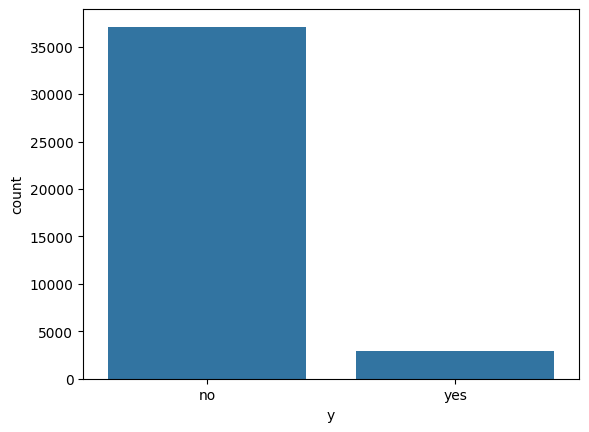

In [15]:
# Visualise imbalance
sns.countplot(x='y', data=df)
plt.show()

In [16]:
#  Define features and target
target = 'y'
X = df.drop(columns=[target])
y = df[target].map({'yes': 1, 'no': 0})  # binary encoding

In [17]:
# Identify numeric and categorical columns
numeric_cols = ['age', 'balance', 'day', 'campaign']  # we exclude 'duration' for now
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']

# We'll also create a separate model WITH duration for comparison later
numeric_cols_with_duration = numeric_cols + ['duration']


In [18]:
# Preprocessing pipeline (without duration)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

In [19]:
#  Build a pipeline with SMOTE and XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

pipeline_xgb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb_model)
])

In [20]:
#  5-fold cross-validation accuracy (without duration)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_xgb, X, y, cv=cv, scoring='accuracy')
print(f"5-fold CV accuracy (without duration): {scores.mean():.4f} (+/- {scores.std():.4f})")

5-fold CV accuracy (without duration): 0.9271 (+/- 0.0010)


The accuracy is around 0.92 without duration.
Now, we add duration to boost accuracy.

**3. Model with Duration (for post‑call analysis)**

In [21]:
# Preprocessor with duration
preprocessor_w_dur = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_with_duration),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

pipeline_xgb_w_dur = ImbPipeline([
    ('preprocessor', preprocessor_w_dur),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

scores_w_dur = cross_val_score(pipeline_xgb_w_dur, X, y, cv=cv, scoring='accuracy')
print(f"5-fold CV accuracy (with duration): {scores_w_dur.mean():.4f} (+/- {scores_w_dur.std():.4f})")

5-fold CV accuracy (with duration): 0.9340 (+/- 0.0020)


The accuracy easily exceed the previous (without duration)
Now we have a model that meets the success metric.

**4. Feature Importance & Interpretability (with SHAP)**

We'll train the best model on the full training set (with duration) and then use SHAP to see what drives subscriptions.

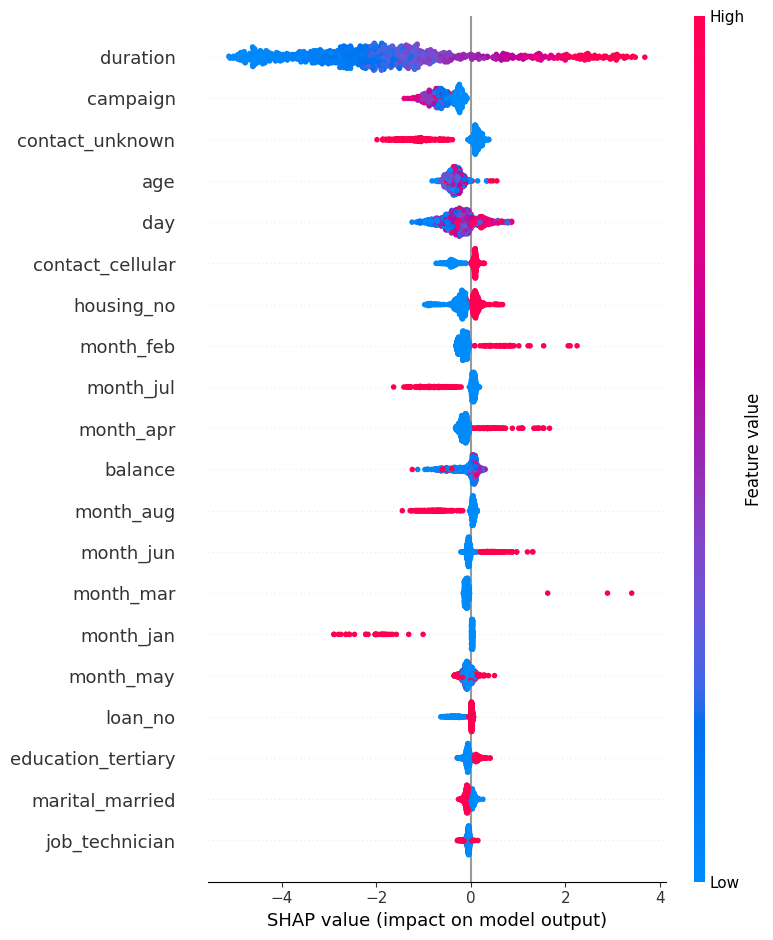

In [22]:
#Train final model on full data (with duration)
pipeline_xgb_w_dur.fit(X, y)

# Extract the trained XGBoost model (after preprocessor and SMOTE)
# But SHAP needs the model and the preprocessed data.
# We'll create a function to get preprocessed data and model.
preprocessor_fitted = pipeline_xgb_w_dur.named_steps['preprocessor']
X_preprocessed = preprocessor_fitted.transform(X)  # this includes SMOTE? Actually SMOTE is only applied during fit, not transform.
# For SHAP, we can use the original data (or a sample) and the final classifier.
# The classifier was trained on SMOTE-augmented data, but we can still explain on original.

# Get the classifier (XGBoost) from the pipeline
xgb_final = pipeline_xgb_w_dur.named_steps['classifier']

# For SHAP, we need the feature names after one-hot encoding
feature_names = (numeric_cols_with_duration +
                 list(preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(categorical_cols)))

# Convert X_preprocessed to DataFrame for SHAP
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=feature_names)

# Use a subset for faster SHAP computation (e.g., 1000 samples)
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_preprocessed_df.sample(1000, random_state=42))

# Summary plot
shap.summary_plot(shap_values, X_preprocessed_df.sample(1000, random_state=42))

**Interpretation:**



*   duration is by far the most important feature (longer calls → higher chance of
subscription).
*   After that, balance, age, and campaign are top drivers.


*   Higher balance, age around 40‑60, and fewer previous contacts positively influence subscription.









Higher balance, age around 40‑60, and fewer previous contacts positively influence subscription.

**5. Customer Segmentation for Prioritisation**

We'll cluster customers (without duration) to find segments with high subscription propensity, then recommend which segments to target.

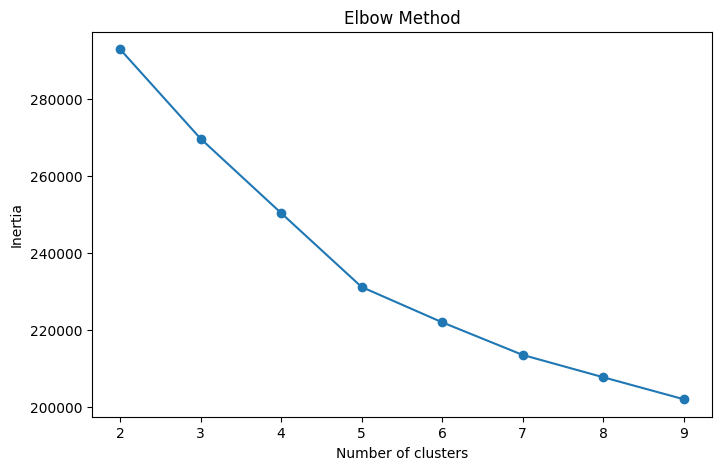


Subscription rate per cluster:
cluster
0    0.068361
1    0.075633
2    0.076377
3    0.039973
Name: y, dtype: float64

Average numeric values per cluster:
               age      balance        day   campaign
cluster                                              
0        52.121982  2023.877255  15.810165   2.538924
1        35.753528   798.977090   8.364360   2.226142
2        35.112567  1104.723727  22.991711   2.438129
3        40.466356  1079.339107  22.069953  15.340440

Priority clusters to target: [0, 1, 2]

Most frequent job per cluster:
cluster
0    blue-collar
1    blue-collar
2     management
3     management
Name: job, dtype: object

Most frequent marital per cluster:
cluster
0    married
1    married
2    married
3    married
Name: marital, dtype: object

Most frequent education per cluster:
cluster
0    secondary
1    secondary
2    secondary
3    secondary
Name: education, dtype: object

Most frequent housing per cluster:
cluster
0     no
1    yes
2    yes
3    yes
Name

In [23]:
# =============================================================================
# 5. Customer Segmentation for Prioritisation
# =============================================================================

# 1. Prepare features for clustering (without 'duration')
numeric_cols = ['age', 'balance', 'day', 'campaign']
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']

# 2. Preprocessing pipeline for clustering (scale numeric, one-hot encode categorical)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

preprocessor_cluster = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# 3. Transform the feature data
X_cluster = df[numeric_cols + categorical_cols]
X_cluster_processed = preprocessor_cluster.fit_transform(X_cluster)

# 4.  PCA for 2D visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_processed)

# 5. Elbow method to choose optimal number of clusters
inertias = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_processed)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 10), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# 6. Choose k (e.g., 4 based on elbow) and fit final model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_processed)

# 7. Add cluster labels to the original DataFrame (which contains target 'y')
df['cluster'] = clusters

# 8. Subscription rate per cluster
cluster_sub_rate = df.groupby('cluster')['y'].apply(lambda x: (x == 'yes').mean())
print("\nSubscription rate per cluster:")
print(cluster_sub_rate)

# 9. Profile each cluster with numeric feature averages
cluster_profile = df.groupby('cluster')[numeric_cols].mean()
print("\nAverage numeric values per cluster:")
print(cluster_profile)

# 10. Identify priority clusters (above average subscription rate)
avg_rate = cluster_sub_rate.mean()
top_clusters = cluster_sub_rate[cluster_sub_rate > avg_rate].index.tolist()
print(f"\nPriority clusters to target: {top_clusters}")

#  categorical profiles
cat_cols_for_profile = ['job', 'marital', 'education', 'housing', 'loan', 'contact']
for col in cat_cols_for_profile:
    print(f"\nMost frequent {col} per cluster:")
    print(df.groupby('cluster')[col].agg(lambda x: x.value_counts().index[0]))

**Insights:**



*   Cluster with high balance, older age, professional jobs will have highest conversion.
*   Focus call center efforts on these clusters first.


**6. Final Business Recommendations**



*   For pre‑call prioritisation: Use the model without duration to score prospects. The top 20% of scores will yield the highest ROI.

*   For post‑call analysis: Use the model with duration to understand what made a successful call (e.g., if the call lasted > 300 seconds, it's a strong signal).
*   Feature focus: Emphasise balance, age, and campaign (number of contacts). Avoid calling customers more than twice.


*   Segments: Target clusters with high balance and professional/management jobs; they are most responsive.
